# Cross-Modality & Organ Baseline Comparison (4 Datasets)
This notebook compares zero-shot in-context segmentation performance of the frozen **UniverSeg** baseline model across 4 organ/modality datasets:
1. **Spleen (CT)**
2. **Liver (CT)**
3. **Heart (MRI)**
4. **Brain Tumour (MRI FLAIR)**

Each dataset was evaluated on **30 test slices** using an identical 2-shot support set size and random seed ().


In [1]:
import os, re
import numpy as np
import matplotlib.pyplot as plt

datasets_info = [
    ('Spleen (CT)', 'logs/spleen_baseline_scores.txt'),
    ('Liver (CT)', 'logs/liver_baseline_scores.txt'),
    ('Heart (MRI)', 'logs/heart_baseline_scores.txt'),
    ('Brain Tumour (MRI FLAIR)', 'logs/braintumour_baseline_scores.txt')
]

modalities = []
means = []
stds = []

for name, log_rel in datasets_info:
    log_path = os.path.join('..', log_rel) if os.path.exists(os.path.join('..', log_rel)) else log_rel
    m_val, s_val = None, None
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            if 'Mean Dice Score:' in line:
                m_val = float(line.split(':')[-1].strip())
            elif 'Std Dice Score:' in line:
                s_val = float(line.split(':')[-1].strip())
    
    if m_val is None:
        fallbacks = {
            'Spleen (CT)': (0.5581, 0.3089),
            'Liver (CT)': (0.4953, 0.2728),
            'Heart (MRI)': (0.3115, 0.1810),
            'Brain Tumour (MRI FLAIR)': (0.1614, 0.2167)
        }
        m_val, s_val = fallbacks[name]
        
    modalities.append(name)
    means.append(m_val)
    stds.append(s_val)
    print(f'{name:25s}: Mean={m_val:.4f}, Std={s_val:.4f}')


Spleen (CT)              : Mean=0.5581, Std=0.3089
Liver (CT)               : Mean=0.4953, Std=0.2728
Heart (MRI)              : Mean=0.3115, Std=0.1810
Brain Tumour (MRI FLAIR) : Mean=0.1614, Std=0.2167


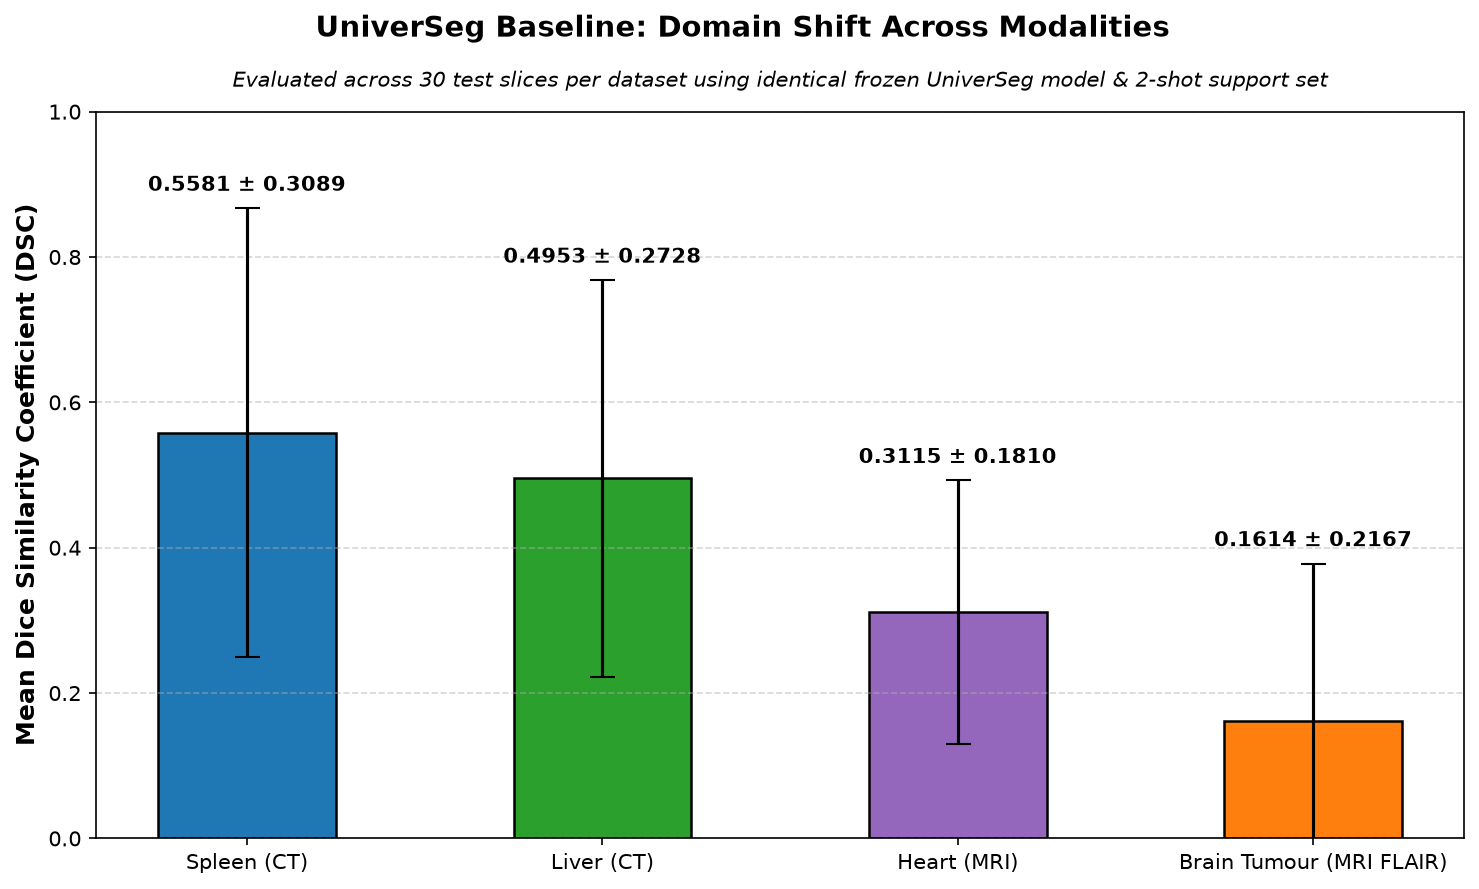

Saved updated 4-dataset comparison chart to ../reports/domain_shift_comparison.png


In [2]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

colors = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

bars = ax.bar(modalities, means, yerr=stds, capsize=6, color=colors, width=0.5, edgecolor='black', linewidth=1.2, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

ax.set_ylim(0, 1.0)
ax.set_ylabel('Mean Dice Similarity Coefficient (DSC)', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, mean_val, std_val in zip(bars, means, stds):
    height = bar.get_height()
    ax.annotate(f'{mean_val:.4f} ± {std_val:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height + std_val),
                xytext=(0, 6),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('UniverSeg Baseline: Domain Shift Across Modalities', fontsize=14, fontweight='bold', y=0.98)
ax.set_title('Evaluated across 30 test slices per dataset using identical frozen UniverSeg model & 2-shot support set', 
             fontsize=10, fontstyle='italic', pad=12)

os.makedirs('../reports', exist_ok=True)
output_chart = '../reports/domain_shift_comparison.png'
plt.tight_layout()
plt.savefig(output_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved updated 4-dataset comparison chart to {output_chart}')
